In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Generate Dataset

In [18]:
df=pd.read_csv('/content/employee_performance.csv')

In [19]:
df.describe()

,Employee_ID,Age,Salary,Projects_Completed,Working_Hours,Performance_Score
count,4000.000000,4000.000000,4000.00000,4000.00000,4000.000000,4000.000000
mean,2000.500000,40.514750,54978.96850,5.01200,44.878575,65.074450
std,1154.844867,10.786119,12020.87937,2.21745,8.067694,14.691439
min,1.000000,22.000000,25000.00000,0.00000,20.000000,11.700000
25%,1000.750000,31.000000,46826.25000,3.00000,39.500000,55.100000
50%,2000.500000,40.000000,54983.00000,5.00000,44.800000,65.300000
75%,3000.250000,50.000000,63167.00000,6.00000,50.425000,75.000000
max,4000.000000,59.000000,98193.00000,16.00000,73.100000,100.000000


---
## 💻 Part B — Practical
### 1 — Central Tendency & Dispersion

In [20]:
salary = df['Salary']
projects = df['Projects_Completed']

print('===== Salary =====')
print(f'Mean   : {salary.mean():,.2f}')
print(f'Median : {salary.median():,.2f}')
print(f'Mode   : {salary.mode()[0]:,}')

print('\n===== Projects Completed =====')
print(f'Variance  : {projects.var():.4f}')
print(f'Std Dev   : {projects.std():.4f}')

===== Salary =====
Mean   : 54,978.97
Median : 54,983.00
Mode   : 25,000

===== Projects Completed =====
Variance  : 4.9171
Std Dev   : 2.2175


### 2 — Probability & Events

In [21]:
# Overall promotion probability
promo_count = (df['Promotion_Status'] == 'Yes').sum()
p_promo = promo_count / len(df)
print(f'P(Promotion) = {promo_count}/{len(df)} = {p_promo:.4f} ({p_promo*100:.2f}%)')

P(Promotion) = 1978/4000 = 0.4945 (49.45%)


In [22]:
# Contingency table
contingency = pd.crosstab(df['Department'], df['Promotion_Status'])
print('Contingency Table — Promotion_Status vs Department:')
contingency

Contingency Table — Promotion_Status vs Department:


Promotion_Status,No,Yes
Department,,
Finance,409,368
HR,417,412
IT,400,368
Marketing,399,418
Operations,397,412


In [23]:
# Conditional probability: P(Promotion | Performance_Score > 80)
high = df[df['Performance_Score'] > 80]
cond_prob = (high['Promotion_Status'] == 'Yes').sum() / len(high)
print(f'P(Promotion | Score > 80) = {cond_prob:.4f} ({cond_prob*100:.2f}%)')
print(f'Based on {len(high)} employees with Performance Score > 80')

P(Promotion | Score > 80) = 0.5916 (59.16%)
Based on 617 employees with Performance Score > 80


### 3 — Distributions & Visualization

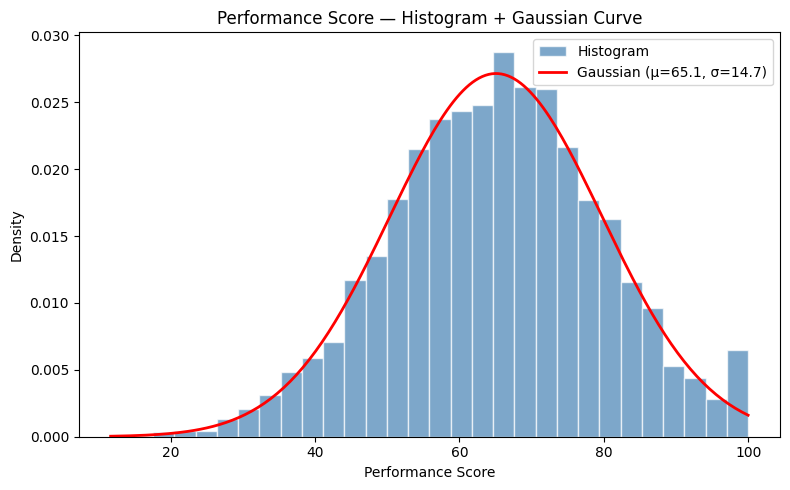

In [24]:
# Plot 1: Histogram of Performance_Score + Gaussian curve
fig, ax = plt.subplots(figsize=(8, 5))
score = df['Performance_Score']

ax.hist(score, bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='Histogram')

mu, sigma = score.mean(), score.std()
x = np.linspace(score.min(), score.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Gaussian (μ={mu:.1f}, σ={sigma:.1f})')

ax.set_title('Performance Score — Histogram + Gaussian Curve')
ax.set_xlabel('Performance Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

Salary  → Skewness: 0.0499 | Kurtosis: -0.1664
Score   → Skewness: -0.0659 | Kurtosis: -0.1013


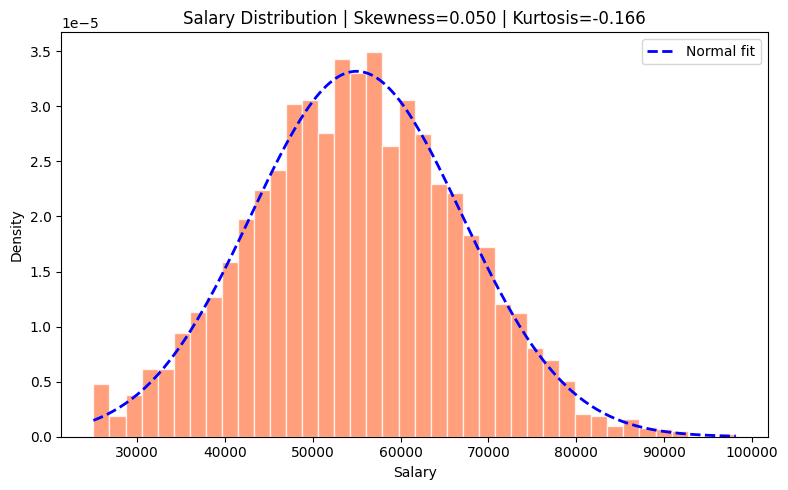

In [25]:
# Skewness and Kurtosis for Salary
sal_skew = salary.skew()
sal_kurt = salary.kurtosis()
sc_skew = score.skew()
sc_kurt = score.kurtosis()

print(f'Salary  → Skewness: {sal_skew:.4f} | Kurtosis: {sal_kurt:.4f}')
print(f'Score   → Skewness: {sc_skew:.4f} | Kurtosis: {sc_kurt:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(salary, bins=40, density=True, color='coral', alpha=0.75, edgecolor='white')
xs = np.linspace(salary.min(), salary.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, salary.mean(), salary.std()), 'b--', linewidth=2, label='Normal fit')
ax.set_title(f'Salary Distribution | Skewness={sal_skew:.3f} | Kurtosis={sal_kurt:.3f}')
ax.set_xlabel('Salary')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

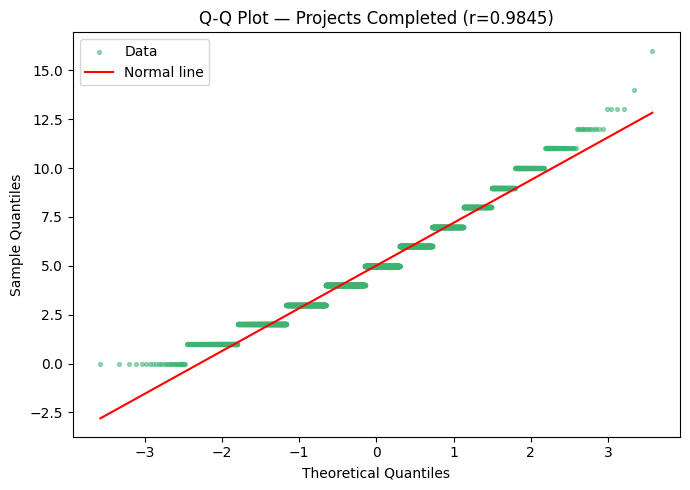

r = 0.9845 — Points deviate from the line because Projects_Completed follows Poisson, not Normal.


In [26]:
# Q-Q Plot for Projects_Completed
fig, ax = plt.subplots(figsize=(7, 5))
(osm, osr), (slope, intercept, r) = stats.probplot(df['Projects_Completed'], dist='norm')
ax.scatter(osm, osr, color='mediumseagreen', s=8, alpha=0.5, label='Data')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label='Normal line')
ax.set_title(f'Q-Q Plot — Projects Completed (r={r:.4f})')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend()
plt.tight_layout()
plt.show()

print(f'r = {r:.4f} — Points deviate from the line because Projects_Completed follows Poisson, not Normal.')

### 4 — Linear Algebra Application

In [27]:
# First 5 employees as vectors [Projects_Completed, Working_Hours]
first5 = df[['Employee_ID', 'Projects_Completed', 'Working_Hours']].head(5)
print('First 5 Employees:')
first5

First 5 Employees:


,Employee_ID,Projects_Completed,Working_Hours
0,1,3,46.1
1,2,7,45.8
2,3,2,60.0
3,4,6,44.7
4,5,4,29.8


In [28]:
v1 = first5[['Projects_Completed', 'Working_Hours']].iloc[0].values.astype(float)
v2 = first5[['Projects_Completed', 'Working_Hours']].iloc[1].values.astype(float)

print(f'Employee 1 vector: {v1}')
print(f'Employee 2 vector: {v2}')

# Dot product
dot = np.dot(v1, v2)
print(f'\nDot Product (v1 · v2) = {dot:.2f}')
print('→ Measures overall similarity in work profile between two employees')

Employee 1 vector: [ 3.  46.1]
Employee 2 vector: [ 7.  45.8]

Dot Product (v1 · v2) = 2132.38
→ Measures overall similarity in work profile between two employees


In [29]:
# Norm 1 and Norm 2 of Employee 1
norm1 = np.linalg.norm(v1, ord=1)
norm2 = np.linalg.norm(v1, ord=2)

print(f'Employee 1 — Norm 1 (Manhattan) : {norm1:.4f}')
print(f'Employee 1 — Norm 2 (Euclidean) : {norm2:.4f}')
print('\nNorm 1 = |Projects| + |Hours| (sum of absolute values)')
print('Norm 2 = sqrt(Projects² + Hours²) (straight-line distance from origin)')

Employee 1 — Norm 1 (Manhattan) : 49.1000
Employee 1 — Norm 2 (Euclidean) : 46.1975

Norm 1 = |Projects| + |Hours| (sum of absolute values)
Norm 2 = sqrt(Projects² + Hours²) (straight-line distance from origin)


In [30]:
# Angle between v1 and v2
cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
cos_theta = np.clip(cos_theta, -1, 1)
angle_deg = np.degrees(np.arccos(cos_theta))

print(f'cos(θ) = {cos_theta:.4f}')
print(f'Angle between Employee 1 and Employee 2 = {angle_deg:.2f}°')

if angle_deg < 30:
    print('→ Very similar working styles (small angle)')
elif angle_deg < 60:
    print('→ Moderately similar working styles')
else:
    print('→ Very different working styles (large angle)')

cos(θ) = 0.9962
Angle between Employee 1 and Employee 2 = 4.97°
→ Very similar working styles (small angle)


---
## 💡 Key Insights

KEY INSIGHTS
1. Employees with Score > 80 have 59.2% promotion chance.
2. Marketing dept has highest promotion rate: 51.2%
3. Average salary = ₹54,979
4. Only 15.4% employees score above 80.
5. Salary skewness = 0.050 → nearly symmetric, balanced pay scale.


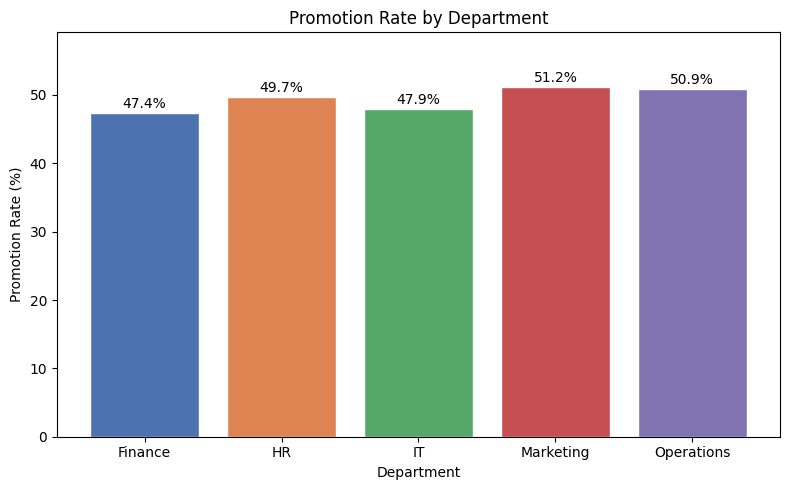

In [31]:
dept_promo = df.groupby('Department')['Promotion_Status'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)

print('KEY INSIGHTS')
print('='*55)
print(f'1. Employees with Score > 80 have {cond_prob*100:.1f}% promotion chance.')
print(f'2. {dept_promo.idxmax()} dept has highest promotion rate: {dept_promo.max():.1f}%')
print(f'3. Average salary = ₹{salary.mean():,.0f}')
print(f'4. Only {(df["Performance_Score"]>80).mean()*100:.1f}% employees score above 80.')
print(f'5. Salary skewness = {sal_skew:.3f} → nearly symmetric, balanced pay scale.')

# Promotion rate bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dept_promo.index, dept_promo.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
              edgecolor='white')
for bar, val in zip(bars, dept_promo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Promotion Rate by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Promotion Rate (%)')
ax.set_ylim(0, dept_promo.max() + 8)
plt.tight_layout()
plt.show()